In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split     # machinine learn cheyikan ayittu scikit(sklearn) le model_selection ninum train_test_split import cheyikum adh data ye split akki machinine learn cheyikum

from sklearn.linear_model import LinearRegression  # LinearRegression enna algorithm anu idhil use cheyounadh

from sklearn import metrics # ethratholam effective anu model ennn ariyan vendi use akunnu


In [ ]:
insurance_dataset=pd.read_csv('/insurance (1).csv') # data read akkan use cheyounnu
insurance_dataset

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
insurance_dataset.head() # adhyathe 5 raws automaticly varum adhalla namal kodukkunadh etre ano adhinanusarich raws varum

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
insurance_dataset.shape #shape kandupidikan adhayadh total etra raw undennum total etra column undennum kanikan

(1338, 7)

In [ ]:
insurance_dataset.info()
#quick data inspection and identifying missing values or incorect data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
insurance_dataset.isnull().sum() # missing values kanikan vendi. missing anu ennundel adh fill akunnadh kanikanam



,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
insurance_dataset.describe()  #statistical data kanikan vendi eg:count,mean ,25%,.....etc

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<Figure size 600x600 with 0 Axes>

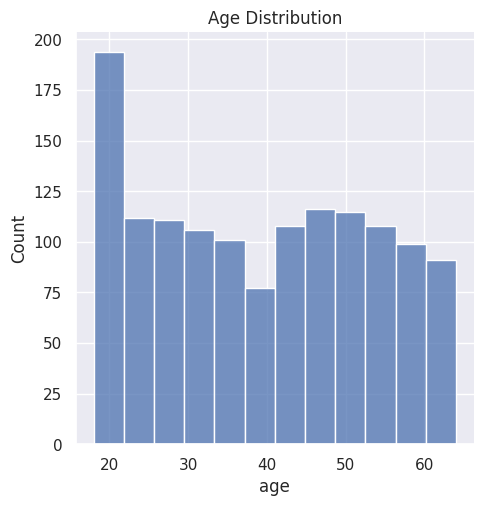

In [ ]:
sns.set() #  sns lott set enna funcion enable cheydhu vekunnu
plt.figure(figsize=(6,6)) # figure plot cheyounna samayath adhinte figsize kanan vendi
sns.displot(insurance_dataset["age"]) # data stile age enna column the select cheydh plot cheyounnu
plt.title("Age Distribution") #graphinte title endhano vendath enn kodukan
plt.show() # graph kanan vendi

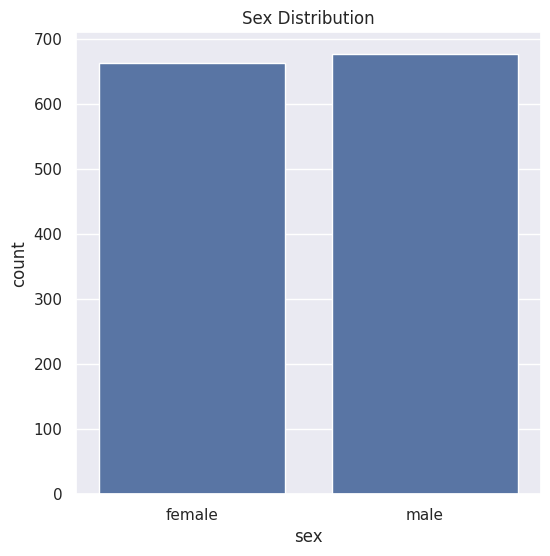

In [ ]:
plt.figure(figsize=(6,6))
sns.countplot(x="sex",data=insurance_dataset) #countplot plot cheyan vendi use akunnu
plt.title("Sex Distribution")
plt.show()

In [ ]:
insurance_dataset['sex'].value_counts() #oronintem value ethre undennu ariyan vendi

,count
sex,
male,676
female,662


/tmp/ipykernel_855/3887342424.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_dataset["bmi"])


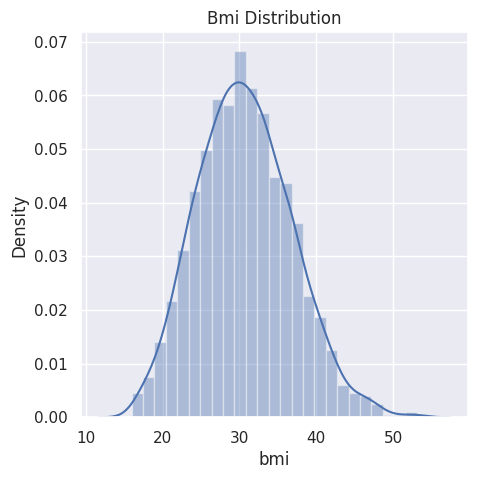

In [ ]:
plt.figure(figsize=(5,5))
sns.distplot(insurance_dataset["bmi"])
plt.title("Bmi Distribution")
plt.show()

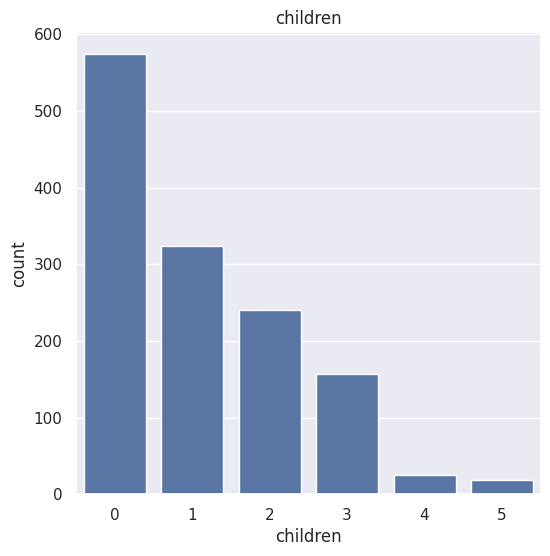

In [ ]:
plt.figure(figsize=(6,6))
sns.countplot(x="children",data=insurance_dataset)
plt.title("children")
plt.show()

In [ ]:
insurance_dataset['children'].value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


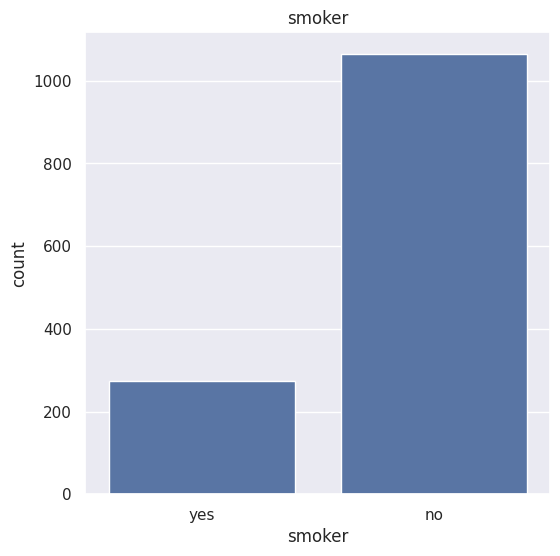

In [ ]:
plt.figure(figsize=(6,6))
sns.countplot(x="smoker",data=insurance_dataset)
plt.title("smoker")
plt.show()

In [ ]:
insurance_dataset['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


<Axes: xlabel='region', ylabel='count'>

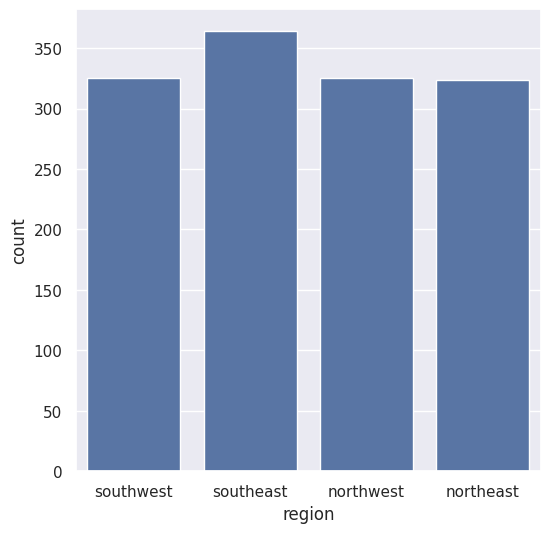

In [ ]:
plt.figure(figsize=(6,6))
sns.countplot(x='region',data=insurance_dataset)


In [ ]:
insurance_dataset['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


<Figure size 600x600 with 0 Axes>

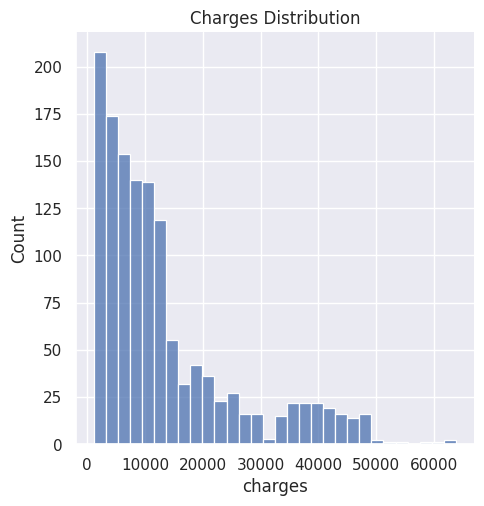

In [ ]:
sns.set()
plt.figure(figsize=(6,6))
sns.displot(insurance_dataset['charges'])
plt.title("Charges Distribution")
plt.show()

In [ ]:
insurance_dataset.replace({'sex':{"male":0,'female':1}},inplace=True)

/tmp/ipykernel_855/3955892602.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_dataset.replace({'sex':{"male":0,'female':1}},inplace=True)


In [ ]:
insurance_dataset.replace({'smoker':{'yes':0,'no':1}},inplace=True)

/tmp/ipykernel_855/353142878.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_dataset.replace({'smoker':{'yes':0,'no':1}},inplace=True)


In [ ]:
insurance_dataset.replace({'region':{'southeast':0,'southwest':1,'northeast':2,'northwest':3}},inplace=True)

/tmp/ipykernel_855/2291917516.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_dataset.replace({'region':{'southeast':0,'southwest':1,'northeast':2,'northwest':3}},inplace=True)


In [ ]:
insurance_dataset

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,1,16884.92400
1,18,0,33.770,1,1,0,1725.55230
2,28,0,33.000,3,1,0,4449.46200
3,33,0,22.705,0,1,3,21984.47061
4,32,0,28.880,0,1,3,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,1,3,10600.54830
1334,18,1,31.920,0,1,2,2205.98080
1335,18,1,36.850,0,1,0,1629.83350
1336,21,1,25.800,0,1,1,2007.94500


In [ ]:
X=insurance_dataset.drop(columns='charges',axis=1)
Y=insurance_dataset['charges']

In [ ]:
print(X)

      age  sex     bmi  children  smoker  region
0      19    1  27.900         0       0       1
1      18    0  33.770         1       1       0
2      28    0  33.000         3       1       0
3      33    0  22.705         0       1       3
4      32    0  28.880         0       1       3
...   ...  ...     ...       ...     ...     ...
1333   50    0  30.970         3       1       3
1334   18    1  31.920         0       1       2
1335   18    1  36.850         0       1       0
1336   21    1  25.800         0       1       1
1337   61    1  29.070         0       0       3

[1338 rows x 6 columns]


In [ ]:
print(Y)

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [ ]:
print(X.shape,X_train.shape,X_test.shape)

(1338, 6) (1070, 6) (268, 6)


In [ ]:
regressor=LinearRegression()

In [ ]:
regressor.fit(X_train,Y_train)

LinearRegression()

In [ ]:
train_prediction=regressor.predict(X_train)
test_prediction=regressor.predict(X_test)

In [ ]:
print(train_prediction)

[  478.49404197  9317.75369733 13193.79859142 ... 17327.55442479
  9600.51860822 13753.18970971]


In [ ]:
validation = metrics.r2_score(Y_test,test_prediction)
validation

0.7447273869684076

In [ ]:
input_data=(31,1,25.74, 0,1,0)
input_data_as_numpy_array=np.asarray(input_data)


input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)


prediction=regressor.predict(input_data_reshaped)
print(prediction)

print('The insurance is USD',prediction[0])

[3760.0805765]
The insurance is USD 3760.080576496057


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
